# 0. Load data

In [125]:
import pandas as pd


In [126]:
#train = pd.read_csv("/Users/nick/Library/CloudStorage/OneDrive-Personal/Programming projects/Team Union 2/Team-Union/Nick/churn_train_cleaned.csv")
train = pd.read_csv("/Users/nick/Library/CloudStorage/OneDrive-Personal/Programming projects/Team Union 2/Team-Union/datasets/resort_train.csv")
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6954 entries, 0 to 6953
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   GuestID         6954 non-null   int64  
 1   BookingDate     6954 non-null   object 
 2   PromoCode       3709 non-null   object 
 3   Region          6785 non-null   object 
 4   AllInclusive    6786 non-null   float64
 5   Room            6568 non-null   object 
 6   PackageType     6801 non-null   object 
 7   Age             6478 non-null   float64
 8   VIP             6796 non-null   float64
 9   RoomService     6490 non-null   float64
 10  Dining          6466 non-null   float64
 11  Retail          6790 non-null   float64
 12  Spa             6806 non-null   float64
 13  Entertainment   6815 non-null   float64
 14  LoyaltyPoints   6954 non-null   int64  
 15  SurveyScore     6954 non-null   int64  
 16  DaysSinceEmail  6954 non-null   int64  
 17  BookingChannel  6954 non-null   o

In [127]:
#Create X and y variables for modeling

from sklearn.model_selection import train_test_split

X = train.drop(['GuestID', 'Churned'], axis=1)
y = train['Churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. XGBoost

Test ROC-AUC:        0.800
Best iteration:      238


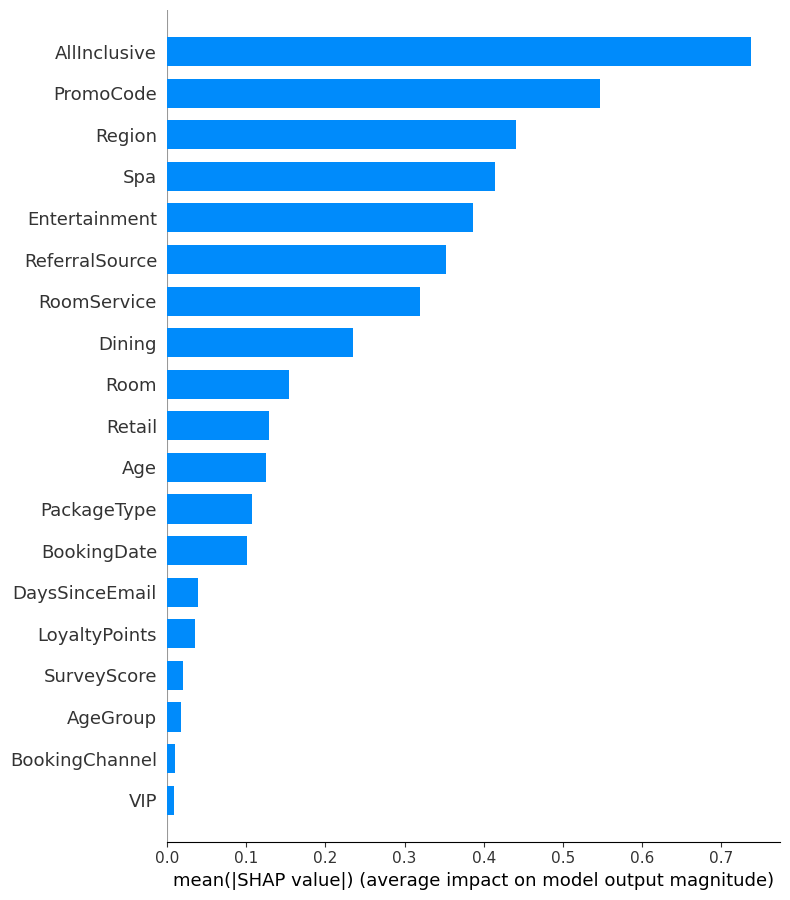

,BookingDate,PromoCode,Region,AllInclusive,Room,PackageType,Age,VIP,RoomService,Dining,Retail,Spa,Entertainment,LoyaltyPoints,SurveyScore,DaysSinceEmail,BookingChannel,AgeGroup,ReferralSource
5487,208,-1,0,1.0,889,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7477,3,161,4,-1,15
5489,453,-1,1,1.0,863,1,2.0,0.0,0.0,0.0,0.0,0.0,0.0,6401,1,19,4,2,17
2133,280,-1,0,1.0,975,2,39.0,0.0,0.0,0.0,0.0,0.0,0.0,9054,5,309,0,1,1
37,465,-1,-1,0.0,1080,1,24.0,0.0,0.0,0.0,17.0,0.0,793.0,9884,5,112,3,4,5
2063,353,0,2,1.0,65,0,31.0,0.0,0.0,0.0,0.0,0.0,0.0,2517,5,25,3,1,5


In [128]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
import shap

# Class imbalance: scale_pos_weight ≈ neg / pos in your training data
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    scale_pos_weight=neg / pos,
    eval_metric="auc",
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1
)

# Convert categorical columns to numeric
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

categorical_cols = X_train_encoded.select_dtypes(include=['object']).columns
for col in categorical_cols:
    X_train_encoded[col] = X_train_encoded[col].astype('category').cat.codes
    X_test_encoded[col] = X_test_encoded[col].astype('category').cat.codes

xgb.fit(X_train_encoded, y_train, eval_set=[(X_test_encoded, y_test)], verbose=False)

probs = xgb.predict(X_test_encoded)
print(f"Test ROC-AUC:        {roc_auc_score(y_test, probs):.3f}")
print(f"Best iteration:      {xgb.best_iteration}")

# Explain individual predictions with SHAP — critical for stakeholder trust
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test_encoded)
shap.summary_plot(shap_values, X_test_encoded, plot_type="bar")

X_test_encoded.head()

# 2. CatBoost

In [ ]:
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_validate

# CatBoost handles categoricals natively — just tell it which columns are categorical.
# GuestID is an identifier, drop it from features.
drop_cols = ["GuestID", "Churned"]
X = train.drop(columns=drop_cols)
y = train["Churned"]

cat_features = [c for c in X.columns if X[c].dtype == "object"]
# CatBoost requires categorical columns to have no NaN — fill with a sentinel string.
X[cat_features] = X[cat_features].fillna("missing")

from sklearn.model_selection import cross_validate, train_test_split
X_train_cb, X_test_cb, y_train_cb, y_test_cb = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

neg, pos = (y_train_cb == 0).sum(), (y_train_cb == 1).sum()

cat = CatBoostClassifier(
    iterations=1000,
    depth=6,
    learning_rate=0.05,
    l2_leaf_reg=3.0,
    scale_pos_weight=neg / pos,
    eval_metric="AUC",
    early_stopping_rounds=50,
    random_seed=42,
    verbose=False,
)

train_pool = Pool(X_train_cb, y_train_cb, cat_features=cat_features)
test_pool = Pool(X_test_cb, y_test_cb, cat_features=cat_features)

cat.fit(train_pool, eval_set=test_pool)

probs = cat.predict(X_test_cb)
print(f"Test ROC-AUC:        {roc_auc_score(y_test_cb, probs):.3f}")
print(f"Best iteration:      {cat.get_best_iteration()}")

#use scitkit-learn classification report to get precision, recall, f1-score, and support for the test set predictions
from sklearn.metrics import classification_report
y_pred = cat.predict(X_test_cb)
print(classification_report(y_test_cb, y_pred))

# Feature importance
import pandas as pd
fi = pd.DataFrame({
    "feature": X_train_cb.columns,
    "importance": cat.get_feature_importance(train_pool),
}).sort_values("importance", ascending=False)
print(fi.to_string(index=False))

Test ROC-AUC:        0.825
Best iteration:      261
              precision    recall  f1-score   support

           0       0.81      0.85      0.83       690
           1       0.84      0.80      0.82       701

    accuracy                           0.82      1391
   macro avg       0.83      0.82      0.82      1391
weighted avg       0.83      0.82      0.82      1391

       feature  importance
  AllInclusive   13.684815
           Spa   11.261814
        Region   10.525770
     PromoCode    8.842044
 Entertainment    8.790349
   BookingDate    8.291058
ReferralSource    8.280473
   RoomService    8.241872
        Dining    5.924535
          Room    3.009853
        Retail    2.907995
      AgeGroup    2.056901
           Age    1.806512
 LoyaltyPoints    1.743296
   PackageType    1.474370
DaysSinceEmail    1.047144
   SurveyScore    1.036595
BookingChannel    0.986171
           VIP    0.088434
